These are the *actual* volume and flow rate functions, used throughout the chapter.  You can ignore the formulas that define them.

In [3]:
def volume(t):
    return (t-4)**3 / 64 + 3.3

def flow_rate(t):
    return 3*(t-4)**2 / 64

In [18]:
def decreasing_volume(t):
    if t < 5:
        return 10 - (t**2)/5
    else:
        return 0.2*(10-t)**2

**Exercise 8.1** Suppose you start a road trip at noon when your odometer reads
77,641 miles, and you end your road trip at 4:30 in the afternoon with your
odometer reading 77,905 miles. What was your average speed during the trip?

In [2]:
t = 4.5
d = 77905 - 77641
avg_speed = d / t
avg_speed

58.666666666666664

**Exercise 8.2** 
Write a Python function secant
line(f,x1,x2) that takes a
_
function f(x) and two values, x1 and x2, and that returns a new function repre-
senting a secant line over time. For instance, if you ran line = secant
line
_
(f,x1,x2), then line(3) would give you the y value of the secant line at x = 3.

In [4]:
def secant_line(f, x1, x2):
    x_dist = x2 - x1
    y1, y2 = f(x1), f(x2)
    y_dist = y2 - y1
    angle = y_dist / x_dist
    return lambda x: (x - x1)*angle + y1



**Exercise 8.3** Write a function that uses the code from the previous exercise to
plot a secant line of a function f between two given points.

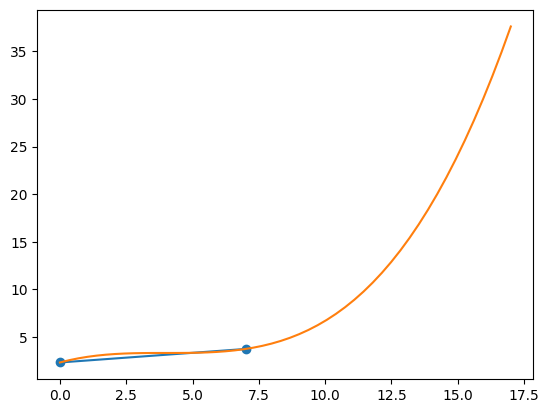

In [17]:
import matplotlib.pyplot as plt
import numpy as np
def plot_secant(f,x1, x2):
    line = secant_line(f, x1, x2)

    x = np.linspace(max(x1 - 10, 0), x2 + 10)
    y = [f(x) for x in x]
    x_sec = np.linspace(x1, x2)
    y_sec = [line(x) for x in x_sec]

    fix, ax = plt.subplots()
    ax.plot(x_sec, y_sec)
    ax.plot(x, y)
    ax.scatter([x1, x2], [f(x1), f(x2)])
    plt.show()



plot_secant(volume, 0, 7)



**Exercise 8.4** Plot the decreasing_
volume flow rates over time at 0.5-hr inter-
vals. When is its flow rate the lowest? That is, when is oil leaving the tank at the
fastest rate?

[0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5]


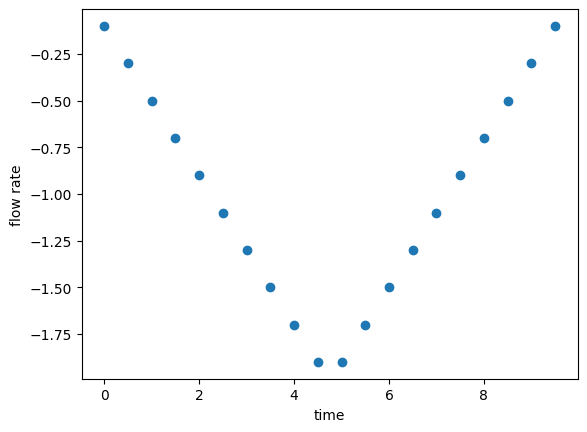

In [ ]:
def avg_flow_rate(f, x1, x2):
    return (f(x2) - f(x1)) / (x2 - x1)


def sample_avg_flow_rate(f, x1, x2, dt=1.0):
    xx = np.arange(x1, x2, dt)
    print(list(xx))
    fig, ax = plt.subplots()
    ax.scatter([x for x in xx], [avg_flow_rate(f, x, x + dt) for x in xx])
    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("Flow rate")
    plt.show()


sample_avg_flow_rate(decreasing_volume, 0, 10, 0.5)

**Exercise:** Write a linear volume function and plot the flow rate over time to show that it is constant.

[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]


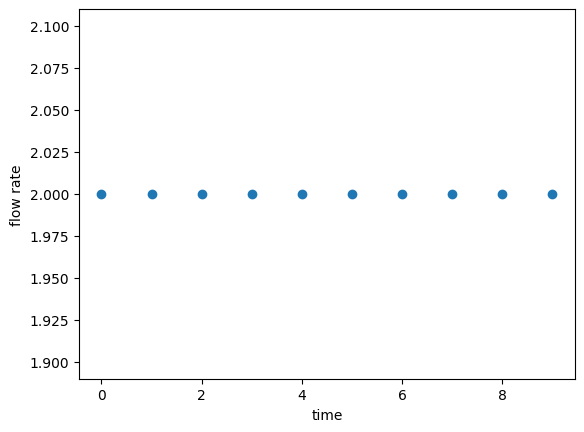

In [32]:
def linear_volume(x):
    return x*2

sample_avg_flow_rate(linear_volume, 0, 10)

**Exercise:** Confirm that the graph of the `volume` function is not a straight line on the interval from 0.999 hours to 1.001 hours.

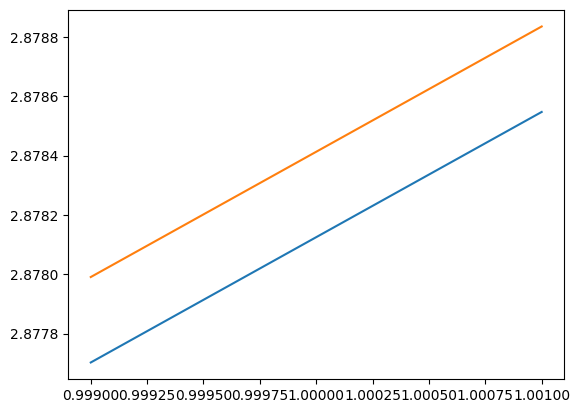

{True: 2, False: 48}

In [42]:
from functools import reduce


x = np.linspace(0.999, 1.001)
y = [volume(x) for x in x]

line = secant_line(volume, 0.999, 1.001)
y_sec = [line(x)*1.0001 for x in x]

_, ax = plt.subplots()
ax.plot(x, y)
ax.plot(x, y_sec)
plt.show()

def calculate_stats(agg, x):
    agg[x] = agg[x] + 1
    return agg
reduce(calculate_stats, [line(x) == volume(x) for x in x], {True: 0, False: 0})

**Exercise:** Approximate the slope of a tangent line to the `volume` graph at $t=8$ by computing the slopes of smaller and smaller secant lines around $t=8$.

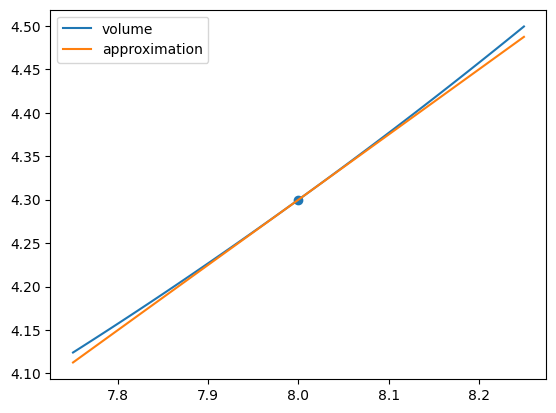

0.7500000001554312


In [115]:
from functools import partial


def approximate_tangent(f, x, digits=7):
    interval = 0.1
    approximate = None
    error_margin = 10**-digits
    
    for _ in range(digits*2):
        x1, x2 = x-interval, x+interval
        if x1 == x2:
            raise ValueError("Not approximatable")
        next_approximate = avg_flow_rate(f, x1, x2)
        if approximate is not None and abs(next_approximate - approximate) <= error_margin:
            return next_approximate
        interval *= 0.1
        approximate = next_approximate

    raise ValueError("Not approximatable")


approximated_flow_rate = partial(approximate_tangent,volume)
angle = approximated_flow_rate(8)

_, ax = plt.subplots()
x = np.linspace(7.75, 8.25)
ax.plot(x, np.vectorize(volume)(x))
ax.plot(x, np.vectorize(lambda x: (x-8)*angle + volume(8) )(x))
ax.scatter([8], [volume(8)])
ax.legend(["volume", "approximation"])
plt.show()

print(angle)
    

**Exercise:** For the sign function defined in Python below, convince yourself that it doesn’t have a derivative at $x=0$.

In [53]:
def sign(x):
    return x / abs(x)
    

In [100]:
tangent, angle = approximate_tangent(sign, 0)

ValueError: Not approximatable

**Exercise:** Approximately how much oil is added to the tank in the first 6 hours?  In the last 4 hours?  During which time interval is more added?


In [122]:
def volume_change(q,t, dt=1.0):
    angle = q(t)
    return angle*dt

dt = 0.01
six_approx, six_exact = sum([volume_change(flow_rate,x, dt) for x in np.arange(0,6, dt)]), volume(6) - volume(0)

last_four_approx, last_four_exact = sum([volume_change(flow_rate, x, dt) for x in np.arange(6, 10, dt)]), volume(10)-volume(6)

six_approx, last_four_approx







(1.1278171874999996, 3.2425031249999257)

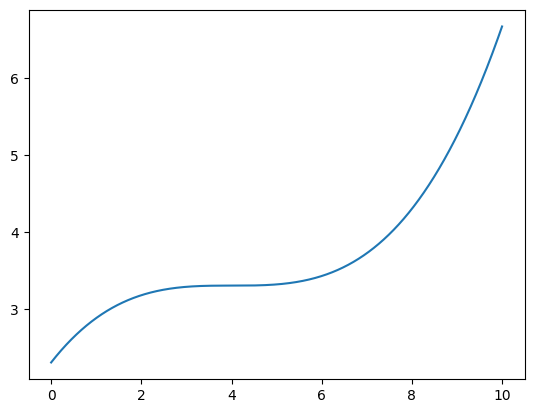

In [125]:
def integrated_volume(q,x1, x2, dt=1.0, initial_value=0.0):
    for x in np.arange(x1, x2, dt):
        yield initial_value
        initial_value += volume_change(q,x,dt)


dt = 0.001
_, ax = plt.subplots()

volume_gen = integrated_volume(flow_rate, 0, 10, dt, volume(0))

ax.plot(np.arange(0, 10, dt), list(volume_gen))
plt.show()
